Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/neel_dw/20260505_06
Device: cpu
Project root content: ['Notebooks', 'data', 'Magnetisation']
Reading from: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/ubermag_data/neel_dw/20260503_02
Bz_NV shape: (256, 256)
Mz_true shape: (256, 256)
Bz_NV range (mT): -302.677 ~ 302.677
Mz_true range (A/m): -580000.0 ~ 580000.0
Bz_NV_mean (mT): 0.0
Bz_NV_centered range (T): -0.302676542590565 ~ 0.302676542590565
scale_factor: 3026.76542590565
Bz_NV_input range (T): -9.999999999999999e-05 ~ 9.999999999999999e-05
[[ 3.62586168e-06  1.08100966e-05  1.77992458e-05 ... -1.77992458e-05
  -1.08100966e-05 -3.62586168e-06]
 [ 3.62486895e-06  1.08071637e-05  1.77945006e-05 ... -1.77945006e-05
  -1.08071637e-05 -3.62486895e-06]
 [ 3.62309807e-06  1.08019290e-05  1.77860221e-

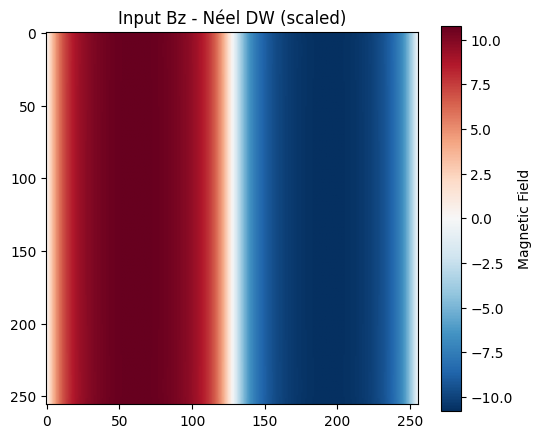

100%|██████████| 500/500 [01:28<00:00,  5.64it/s]


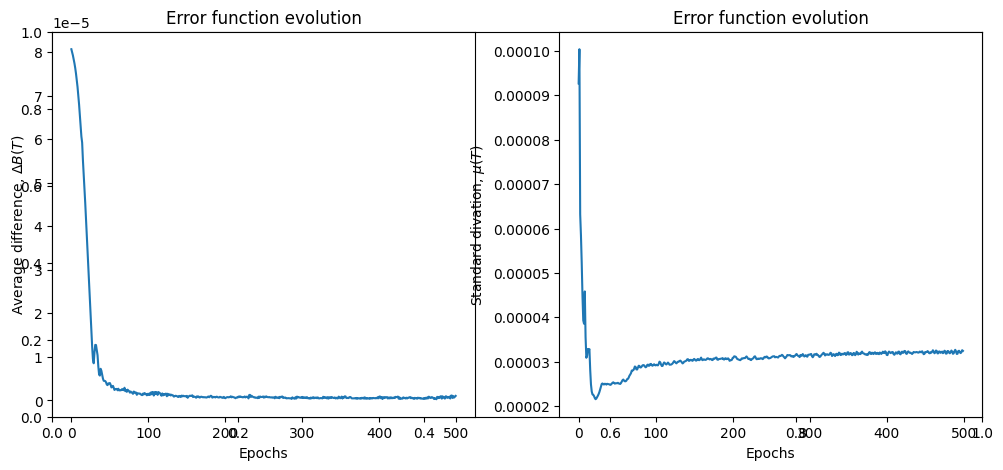

Final MagnetisationMap shape: (256, 256)
Final ReconstructedBnv shape: (256, 256)


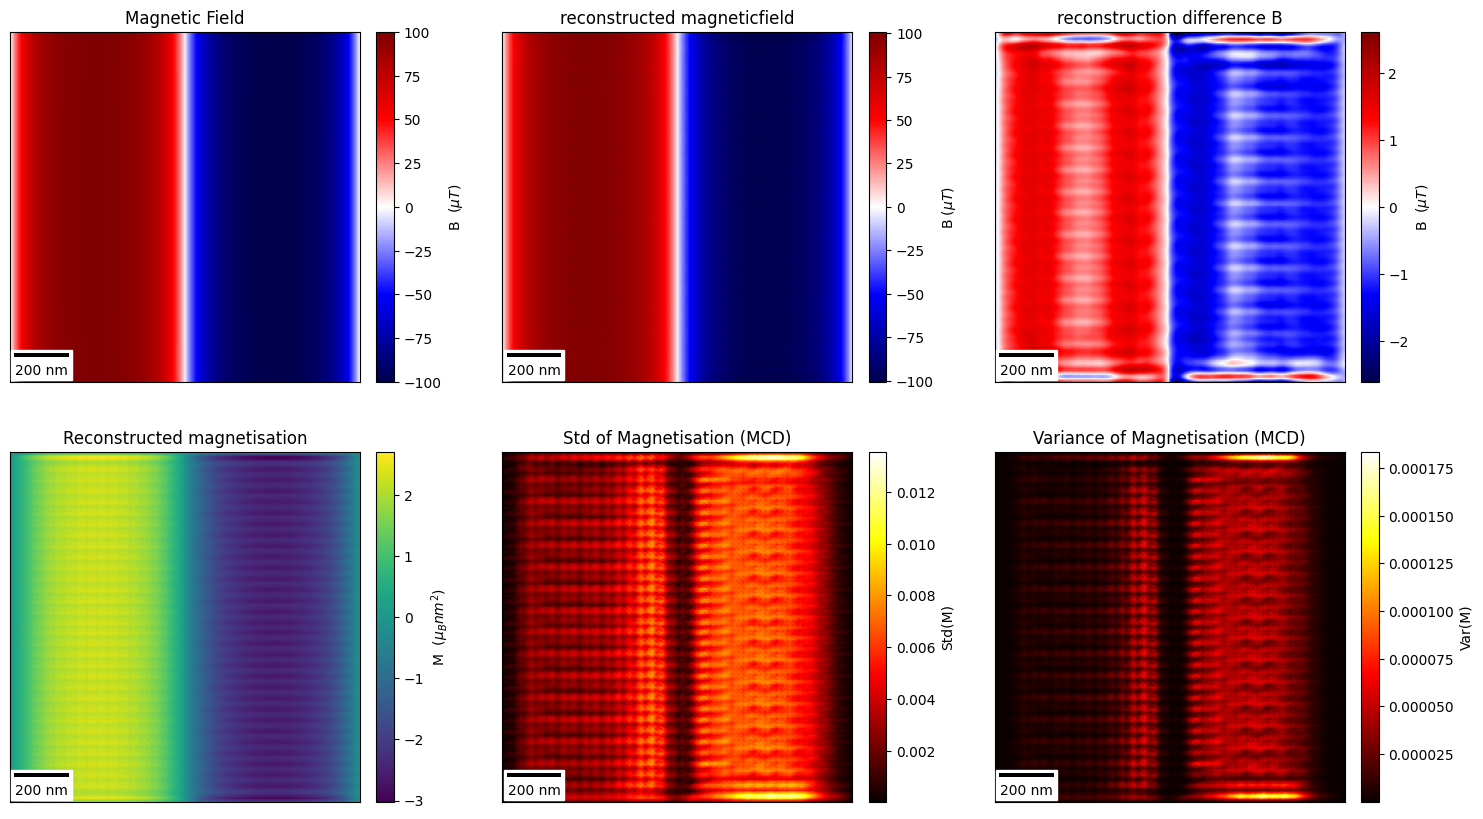

=== MC Dropout Diversity Check ===
M_predicted (MC mean) range: -3.0219 ~ 2.7064
M_std (MC std) range: 0.000029 ~ 0.013541
M_std mean:                0.003905
M_predicted std (spatial): 1.875134
Ratio M_std / M_predicted.std(): 0.002083



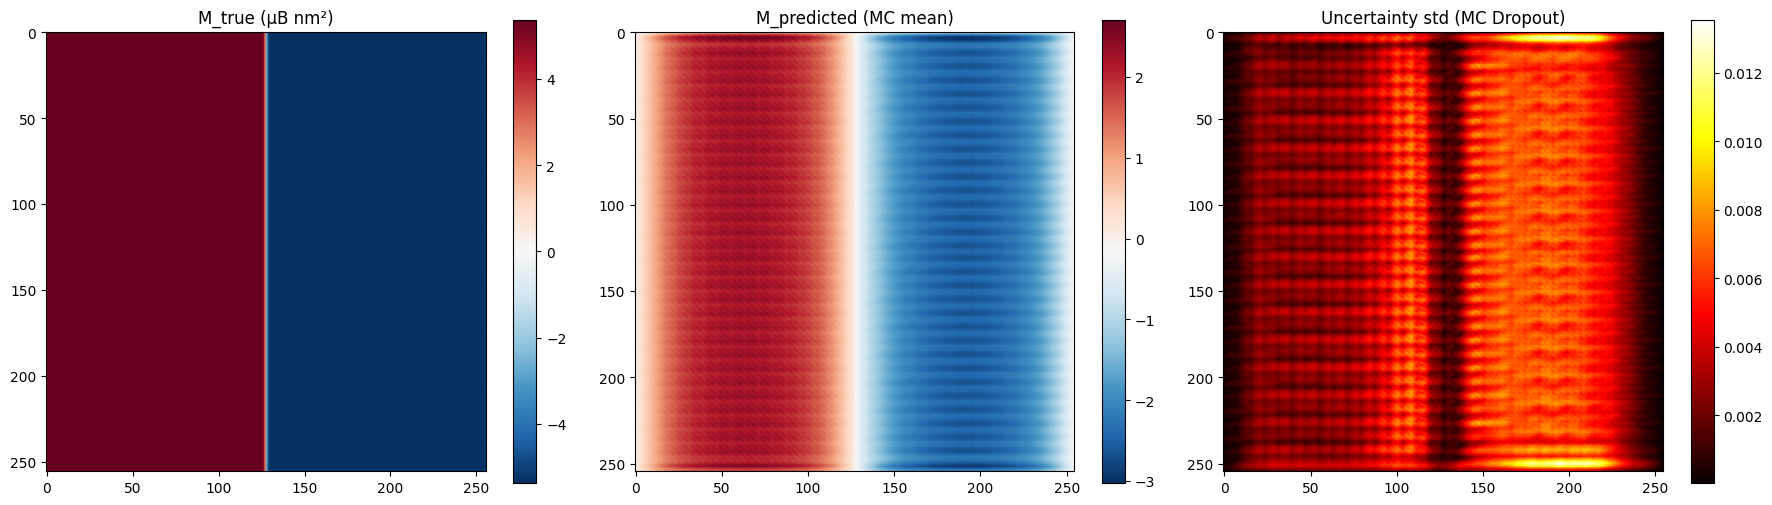

Saved for calibration analysis:
  M_predicted.npy      shape=(255, 255)
  M_std.npy            shape=(255, 255)
  M_true_converted.npy shape=(256, 256)
  → /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/neel_dw/20260505_06

M_true range (μB nm²):   -5.3766 ~ 5.3766
M_predicted range:       -3.0219 ~ 2.7064
M_std range:             2.9448158e-05 ~ 0.013540918
scale_factor used:       3026.76542590565
Bz_NV_centered range (T): -0.302676542590565 ~ 0.302676542590565
Mz_true_centered range (A/m): -579999.9999999977 ~ 579999.9999999977
Mz_true_converted range (μB nm²): -5.376599999999978 ~ 5.376599999999978

All results saved to: /content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/neel_dw/20260505_06

=== Diagnosis ===
Results['Magnetisation'] range: -3.0218854 ~ 2.706414
Results['Magnetisation Std'] range: 2.9448158e-05 ~ 0.013540918
Ratio |M_predicted mean| / M_std mean: 27.541473


In [5]:
# ============================================================
# Ubermag reconstruction of Neel DW
# ============================================================
# Author / 作者: Yue Yu, TU Dresden / ct.qmat

# ======================================================
# Cell 1: 安装和设置 / Setup and Installation
# ======================================================
!pip install matplotlib_scalebar
from google.colab import drive
drive.mount('/content/drive')

import sys, os, glob
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from datetime import datetime

# 自动创建日期序号保存目录
# Automatically create dated output directory
base_save = '/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/uberesult/neel_dw'

date_str = datetime.now().strftime("%Y%m%d")
idx = 1
while os.path.exists(os.path.join(base_save, f"{date_str}_{idx:02d}")):
    idx += 1

save_dir = os.path.join(base_save, f"{date_str}_{idx:02d}")
os.makedirs(save_dir, exist_ok=True)
print("Save directory:", save_dir)

# 加载模型代码 / Load model code
PROJECT_ROOT = "/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/2D"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from Magnetisation.Propagator import Propagator
from Magnetisation.Generator import generator_CNN
from Magnetisation.Train import Magnetisation_CNN_training

# numpy 兼容性修复 / numpy compatibility fix
if not hasattr(np, "int"):
    np.int = int

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("Project root content:", os.listdir(PROJECT_ROOT))

# ======================================================
# Cell 2: 自动读取最新 ubermag neel_dw 数据
# Auto-load Latest ubermag neel_dw Data
# ======================================================
neel_base = '/content/drive/MyDrive/Colab Notebooks/Ubermag_Model_Verification/ubermag_data/neel_dw'

# 自动找最新的日期文件夹 / Automatically find latest dated folder
all_dirs = sorted([d for d in glob.glob(os.path.join(neel_base, "*"))
                   if os.path.isdir(d)])

if all_dirs:
    latest_dir = all_dirs[-1]
    print("Reading from:", latest_dir)
    Bz_NV   = np.load(os.path.join(latest_dir, "Bz_NV_neel_dw.npy"))
    Mz_true = np.load(os.path.join(latest_dir, "Mz_true_neel_dw.npy"))
else:
    # 如果没有日期文件夹，使用旧路径 / Fallback to legacy path
    print("No dated folder found, using legacy path.")
    Bz_NV   = np.load(os.path.join(neel_base, "Bz_NV_neel_dw.npy"))
    Mz_true = np.load(os.path.join(neel_base, "Mz_true_neel_dw.npy"))

print("Bz_NV shape:", Bz_NV.shape)
print("Mz_true shape:", Mz_true.shape)
print("Bz_NV range (mT):", round(Bz_NV.min()*1e3, 3), "~", round(Bz_NV.max()*1e3, 3))
print("Mz_true range (A/m):", round(Mz_true.min(), 1), "~", round(Mz_true.max(), 1))

# ======================================================
# Cell 3: 设置传播参数 + 构建 Propagator
# Setup Propagation Options + Build Propagator
# ======================================================
unit_conversion = 1e-18 / 9.27e-24  # A/m → μB nm²，约等于 107874

# 去掉均匀背景分量，缩放到实验数据量级
# Remove uniform background, scale to match experimental data range
Bz_NV_mean     = Bz_NV.mean()
Bz_NV_centered = Bz_NV - Bz_NV_mean
scale_factor   = np.max(np.abs(Bz_NV_centered)) / 1e-4
Bz_NV_input    = Bz_NV_centered / scale_factor

print("Bz_NV_mean (mT):", round(Bz_NV_mean*1e3, 4))
print("Bz_NV_centered range (T):", Bz_NV_centered.min(), "~", Bz_NV_centered.max())
print("scale_factor:", scale_factor)
print("Bz_NV_input range (T):", Bz_NV_input.min(), "~", Bz_NV_input.max())

# NV 传感器和磁化参数 / NV sensor and magnetisation parameters
PropagationOptions = dict()
PropagationOptions['PixelSize'] = 5e-9          # 像素大小 5 nm / Pixel size 5 nm
PropagationOptions['ImageShape'] = 256           # 图像尺寸 / Image size
PropagationOptions['NV'] = dict()
PropagationOptions['NV']['FindTheta'] = False
PropagationOptions['NV']['Theta'] = 0            # NV 极角 / NV polar angle
PropagationOptions['NV']['FindPhi'] = False
PropagationOptions['NV']['Phi'] = 0              # NV 方位角 / NV azimuthal angle
PropagationOptions['NV']['Height'] = 50e-9       # NV 离样品高度 50 nm / NV standoff height
PropagationOptions['Magnetisation'] = dict()
PropagationOptions['Magnetisation']['FindTheta'] = False
PropagationOptions['Magnetisation']['Theta'] = 0
PropagationOptions['Magnetisation']['FindPhi'] = False
PropagationOptions['Magnetisation']['Phi'] = 0
PropagationOptions['FFT'] = dict()
PropagationOptions["FFT"]["PaddingFactor"] = 4
PropagationOptions["FFT"]["performPadding"] = False
PropagationOptions["FFT"]["PaddingMode"] = 'constant'
PropagationOptions['FFT']['Extended'] = False
PropagationOptions['FFT']['Extention'] = 100
PropagationOptions['FFT']['Filter'] = dict()
PropagationOptions['FFT']['Filter']['useHanning'] = True
PropagationOptions['FFT']['Filter']['useHighCutoff'] = False
PropagationOptions['FFT']['Filter']['useLowCutoff'] = False
PropagationOptions['FFT']['Filter']['LambdaHighCutoff'] = 100e-9
PropagationOptions['FFT']['Filter']['LambdaLowCutoff'] = 7e-06

PROP = Propagator(PropagationOptions, Bz_NV_input, PropagationOptions['ImageShape'])

print("PROP mask unique values:", np.unique(PROP.Mask))
print("PROP MagneticFieldExtended range:",
      round(PROP.MagneticFieldExtended.min(), 4), "~",
      round(PROP.MagneticFieldExtended.max(), 4))

# 可视化输入磁场 / Visualise input magnetic field
plt.figure(figsize=(6, 5))
plt.imshow(PROP.MagneticFieldExtended, cmap='RdBu_r')
plt.colorbar(label='Magnetic Field')
plt.title('Input Bz - Néel DW (scaled)')
plt.savefig(os.path.join(save_dir, '1_input_Bz.png'), dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 4: 固定随机种子，训练神经网络
# Fix Random Seeds, Train Neural Network
# ======================================================
# 固定种子保证结果可重复 / Fix seeds for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

Generator = generator_CNN(Size=1, ImageSize=PROP.options['ImageShape']).to(device)

# 训练参数 / Training parameters
ML_options = dict()
ML_options['mlp'] = False
ML_options['LossFunction'] = 'L1'               # L1 损失函数 / L1 loss function
ML_options['Epochs'] = 500                       # 训练轮数 / Number of training epochs
ML_options['Magnetization'] = None
ML_options['PositiveMagnetisationOnly'] = False  # 允许负磁化 / Allow negative magnetisation
ML_options['PrintLossValue'] = False
ML_options['IntegerOnly'] = False

CNN_training = Magnetisation_CNN_training(device, Generator, PROP, ML_options)
bnv_cnn = CNN_training.train_cnn(**ML_options)
plt.savefig(os.path.join(save_dir, '2_training_loss.png'), dpi=300, bbox_inches='tight')
plt.show()

# ======================================================
# Cell 5: 重建结果（含 MC Dropout 不确定性）
# Reconstruction Results (with MC Dropout Uncertainty)
# ======================================================
# 使用 MC Dropout 进行 100 次前向传播
# Perform 100 stochastic forward passes with MC Dropout
# T = 100 在 Train.py 中定义 / T = 100 defined in Train.py
Results = CNN_training.extract_results(plotResults=True)
plt.savefig(os.path.join(save_dir, '3_reconstruction_results.png'), dpi=300, bbox_inches='tight')
plt.show()

# MC Dropout 多样性检查 / MC Dropout diversity check
print("=== MC Dropout Diversity Check ===")
print(f"M_predicted (MC mean) range: "
      f"{Results['Magnetisation'].min():.4f} ~ "
      f"{Results['Magnetisation'].max():.4f}")
print(f"M_std (MC std) range: "
      f"{Results['Magnetisation Std'].min():.6f} ~ "
      f"{Results['Magnetisation Std'].max():.6f}")
print(f"M_std mean:                {Results['Magnetisation Std'].mean():.6f}")
print(f"M_predicted std (spatial): {Results['Magnetisation'].std():.6f}")
print(f"Ratio M_std / M_predicted.std(): "
      f"{Results['Magnetisation Std'].mean() / Results['Magnetisation'].std():.6f}")
print()
# 比值远小于 1 说明模型低估了不确定性（过于自信）
# Ratio << 1 indicates model underestimates uncertainty (overconfident)

# ======================================================
# Cell 6: 对比 M_true vs M_predicted，保存结果
# Compare M_true vs M_predicted, Save Results
# ======================================================
unit_conversion = 1e-18 / 9.27e-24  # A/m → μB nm²

# 去掉 Mz_true 的均匀背景，与 Bz_NV_input 的处理保持一致
# Remove uniform background from Mz_true, consistent with Bz_NV_input processing
Mz_true_centered  = Mz_true - Mz_true.mean()
Mz_true_converted = Mz_true_centered / unit_conversion  # 转换到 μB nm² / Convert to μB nm²

# 对比图 / Comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(Mz_true_converted, cmap='RdBu_r')
axes[0].set_title('M_true (μB nm²)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(Results['Magnetisation'], cmap='RdBu_r')
axes[1].set_title('M_predicted (MC mean)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(Results['Magnetisation Std'], cmap='hot')
axes[2].set_title('Uncertainty std (MC Dropout)')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, '4_Mtrue_vs_Mpredicted.png'), dpi=300, bbox_inches='tight')
plt.show()

# 保存供校准分析使用 / Save for calibration analysis
np.save(os.path.join(save_dir, 'M_predicted.npy'),
        Results['Magnetisation'])
np.save(os.path.join(save_dir, 'M_std.npy'),
        Results['Magnetisation Std'])
np.save(os.path.join(save_dir, 'M_true_converted.npy'),
        Mz_true_converted)

# 打印数值范围 / Print value ranges
print("Saved for calibration analysis:")
print(f"  M_predicted.npy      shape={Results['Magnetisation'].shape}")
print(f"  M_std.npy            shape={Results['Magnetisation Std'].shape}")
print(f"  M_true_converted.npy shape={Mz_true_converted.shape}")
print(f"  → {save_dir}")
print()
print("M_true range (μB nm²):  ",
      round(Mz_true_converted.min(), 4), "~",
      round(Mz_true_converted.max(), 4))
print("M_predicted range:      ",
      round(Results['Magnetisation'].min(), 4), "~",
      round(Results['Magnetisation'].max(), 4))
print("M_std range:            ",
      Results['Magnetisation Std'].min(), "~",
      Results['Magnetisation Std'].max())
print("scale_factor used:      ", scale_factor)
print("Bz_NV_centered range (T):",
      Bz_NV_centered.min(), "~", Bz_NV_centered.max())
print("Mz_true_centered range (A/m):",
      Mz_true_centered.min(), "~", Mz_true_centered.max())
print("Mz_true_converted range (μB nm²):",
      Mz_true_converted.min(), "~", Mz_true_converted.max())
print("\nAll results saved to:", save_dir)

# 诊断输出 / Diagnostic output
print("\n=== Diagnosis ===")
print("Results['Magnetisation'] range:",
      Results['Magnetisation'].min(), "~",
      Results['Magnetisation'].max())
print("Results['Magnetisation Std'] range:",
      Results['Magnetisation Std'].min(), "~",
      Results['Magnetisation Std'].max())
print("Ratio |M_predicted mean| / M_std mean:",
      abs(Results['Magnetisation'].mean()) /
      Results['Magnetisation Std'].mean())